# BLACKROCK_PROJECT_5

## 1. Data Cleaning and Formatting
#### 1.1 Remove/treat any special characters or non-numeric entries from financial fields.¶

In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df= pd.read_csv("C:/Users/BEAST/course 5 project/blackrock.csv")
df['TransactionAmount'] = pd.to_numeric(df['TransactionAmount'], errors='coerce').fillna(0)
df['AccountBalance'] = pd.to_numeric(df['AccountBalance'], errors='coerce').fillna(0)
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

#### 1.2 Convert currency amounts into numerical format.

In [223]:
df['TransactionAmount'] = df['TransactionAmount'].replace('$', '', regex=False).replace(',', '', regex=False).astype(float)
df['AccountBalance'] = df['AccountBalance'].replace('$', '', regex=False).replace(',', '', regex=False).astype(float)
df['TransactionAmount'].head(5)
df['AccountBalance'].head(5)

0      2980.571037
1     27996.690070
2     81482.156180
3     39598.371940
4    111731.993700
Name: AccountBalance, dtype: float64

#### 1.3 Validate and format date columns.

In [224]:
df['TransactionDate'] =  pd.to_datetime(df ['TransactionDate'],dayfirst=True)
df ['TransactionDate'].head(5)

0   2023-07-17
1   2023-01-13
2   2023-09-28
3   2023-02-05
4   2023-11-19
Name: TransactionDate, dtype: datetime64[ns]

#### 1.4 Ensure account types and transaction categories are standardized.
-This code cleans the AccountType column by removing extra spaces, converting values to text format, changing them into proper case, and correcting inconsistent names like wrong spellings. Finally, it displays the unique standardized account types.

    

In [225]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Standardize AccountType
df['AccountType'] = (df['AccountType'].astype(str).str.strip().str.title().replace({
        'Saving': 'Savings',
        'Current Acc': 'Current',
        'Currnt': 'Current'
    })
)

# Verify cleaned values
print("Unique Account Types:")
print(df['AccountType'].unique())



Unique Account Types:
['Credit' 'Current' 'Loan' 'Savings']


## 2. Descriptive Transactional Analysis
#### 2.1 Calculate monthly and yearly summaries of total credits, debits, and net transaction volumn.¶
-This code first checks unique transaction types and converts TransactionDate into datetime format. It standardizes TransactionType values by removing spaces and formatting text properly. Then it separates transaction amounts into CreditAmount for deposits and DebitAmount for withdrawals/payments. After that, it groups data monthly and yearly to calculate total credits, total debits, and net transaction volume (Credits − Debits). Finally, it prints the monthly and yearly summaries.

In [226]:

df['TransactionType'].unique()
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
# Standardize transaction type text
df["TransactionType"] = df["TransactionType"].str.strip().str.title()

# Classify amounts
df["CreditAmount"] = df["TransactionAmount"].where(df["TransactionType"] == "Deposit", 0)
df["DebitAmount"] = df["TransactionAmount"].where(df["TransactionType"].isin(["Withdrawal", "Payment"]), 0)

# Monthly summary
monthly_summary = (
    df.groupby(df["TransactionDate"].dt.to_period("M"))
    .agg(
        TotalCredits=("CreditAmount", "sum"),
        TotalDebits=("DebitAmount", "sum")
    )
    .reset_index()
)


# Monthly Net volume
monthly_summary["NetTransactionVolume"] = (
    monthly_summary["TotalCredits"] - monthly_summary["TotalDebits"])

# Yearly summary
yearly_summary = (
    df.groupby(df["TransactionDate"].dt.to_period("Y"))
    .agg(
        TotalCredits=("CreditAmount", "sum"),
        TotalDebits=("DebitAmount", "sum")
    )
    .reset_index()
)

# Yearly net volume
yearly_summary["NetTransactionVolume"] =(
     yearly_summary["TotalCredits"] - yearly_summary["TotalDebits"])

print("Monthly Summary")
print(monthly_summary)

print("\nYearly Summary")
print(yearly_summary)

Monthly Summary
   TransactionDate  TotalCredits   TotalDebits  NetTransactionVolume
0          2023-01  4.532878e+05  1.329907e+06         -8.766195e+05
1          2023-02  5.565913e+05  1.674318e+06         -1.117726e+06
2          2023-03  4.055112e+05  1.397223e+06         -9.917113e+05
3          2023-04  3.289578e+05  1.273478e+06         -9.445206e+05
4          2023-05  9.335588e+05  1.320213e+06         -3.866543e+05
5          2023-06  6.760825e+05  5.318630e+05          1.442195e+05
6          2023-07  4.865498e+05  1.047057e+06         -5.605071e+05
7          2023-08  8.198514e+04  1.511240e+06         -1.429255e+06
8          2023-09  7.491474e+05  1.565614e+06         -8.164665e+05
9          2023-10  1.322052e+06  1.973337e+06         -6.512850e+05
10         2023-11  9.661783e+05  1.337323e+06         -3.711449e+05
11         2023-12  5.228622e+05  6.229963e+05         -1.001341e+05
12         2024-01  7.924528e+05  6.735780e+05          1.188748e+05
13         2024-02

#### 2.2 Plot trends in total credits vs. debits over time
-This code sets TransactionDate as the index for time-based analysis. It creates Credit and Debit columns by separating deposit amounts as credits and withdrawal, payment, or transfer amounts as debits. Then it resamples the data monthly and calculates total credits and debits for each month. Finally, it plots a line chart to compare monthly credits and debits over time.


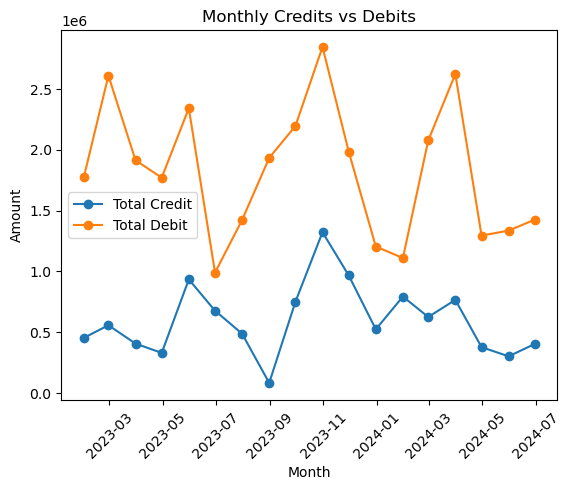

In [227]:
#df.reset_index(inplace=True)

df.set_index('TransactionDate', inplace=True)

df['Credit'] = df['TransactionAmount'].where(df['TransactionType'] == 'Deposit', 0)
df['Debit'] = df['TransactionAmount'].where(df['TransactionType'].isin(["Withdrawal", "Payment",'Transfer']), 0)

# Monthly aggregation
monthly_summary = df.resample('ME')[['Credit', 'Debit']].sum()

plt.figure()
plt.plot(monthly_summary.index, monthly_summary['Credit'], marker='o', label='Total Credit')
plt.plot(monthly_summary.index, monthly_summary['Debit'], marker='o', label='Total Debit')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.title('Monthly Credits vs Debits')
plt.legend()
plt.xticks(rotation=45)
plt.show()


#### 2.3 Identify top and bottom performing accounts based on net inflow¶
-This code first cleans the TransactionType column by removing spaces and standardizing text format. It then creates Inflow for deposit amounts and Outflow for withdrawal or payment amounts. Net inflow (NetFlow) is calculated as inflow minus outflow. After that, the data is grouped by AccountID to find total net flow for each account. Finally, it displays the top 5 performing accounts with highest net inflow and bottom 5 accounts with lowest net inflow.


In [228]:
#df.reset_index(inplace=True)

In [229]:
# Clean TransactionType (important)
df['TransactionType'] = df['TransactionType'].astype(str).str.strip().str.title()

# Convert date (optional but good practice)
#df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True)

# Create inflow (+) and outflow (-)
df['Inflow'] = df['TransactionAmount'].where(df['TransactionType'] == "Deposit", 0)
df['Outflow'] = df['TransactionAmount'].where(df['TransactionType'].isin(["Withdrawal", "Payment"]), 0 )

# Net inflow = inflow - outflow
df['NetFlow'] = df['Inflow'] - df['Outflow']

# Group by AccountID
account_summary = df.groupby('AccountID')['NetFlow'].sum().reset_index()

# Top 5 performing accounts
top_accounts = account_summary.sort_values(by='NetFlow', ascending=False).head(5)

# Bottom 5 performing accounts
bottom_accounts = account_summary.sort_values(by='NetFlow', ascending=True).head(5)



print("Top 5 Performing Accounts")
print(top_accounts)
print("\nBottom 5 Performing Accounts")
print(bottom_accounts)

Top 5 Performing Accounts
    AccountID       NetFlow
170  ACC88286  284230.60079
24   ACC21719  274729.18572
102  ACC51200  201469.73244
43   ACC28295  199450.69292
169  ACC88252  183519.24882

Bottom 5 Performing Accounts
    AccountID        NetFlow
83   ACC45101 -395419.947830
66   ACC35419 -365901.203200
188  ACC97411 -365710.863533
138  ACC71938 -353666.209440
31   ACC24070 -338136.693810


#### 2.4 Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.
-This code resets the index and converts TransactionDate into datetime format. It then sorts the data by AccountID and transaction date. Next, it calculates the number of days between consecutive transactions for each account. If the gap is 60 days or more, the account is marked as dormant; otherwise, it is active. Finally, it prints the list of dormant accounts and shows the records where dormancy occurred.


In [230]:
df.reset_index(inplace=True)

# Convert date column
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True)

# Sort data by AccountID and date
df = df.sort_values(by=['AccountID', 'TransactionDate'])

# Calculate gap (in days) between consecutive transactions per account
df['DaysGap'] = df.groupby('AccountID')['TransactionDate'].diff().dt.days

# Flag dormant accounts (gap >= 60 days ~ 2 months)
df['DormantFlag'] = df['DaysGap'].apply(lambda x: 'Dormant' if x >= 60 else 'Active')

# Extract only dormant cases
dormant_accounts = df[df['DormantFlag'] == 'Dormant']

# Get unique account IDs that are dormant
dormant_account_list = dormant_accounts['AccountID'].unique()

# Print results
print("Dormant Accounts:")
print(dormant_account_list)

# Optional: view full records where dormancy occurred
print(dormant_accounts[['AccountID', 'TransactionDate', 'DaysGap']])

Dormant Accounts:
['ACC10117' 'ACC10996' 'ACC11062' 'ACC11188' 'ACC11285' 'ACC11837'
 'ACC12334' 'ACC13357' 'ACC15228' 'ACC15671' 'ACC15925' 'ACC16241'
 'ACC16664' 'ACC17688' 'ACC18057' 'ACC18140' 'ACC18177' 'ACC19156'
 'ACC19178' 'ACC20297' 'ACC21264' 'ACC21429' 'ACC21719' 'ACC21878'
 'ACC22036' 'ACC22255' 'ACC22799' 'ACC23736' 'ACC23985' 'ACC24070'
 'ACC24508' 'ACC24880' 'ACC24981' 'ACC25811' 'ACC26026' 'ACC26940'
 'ACC26956' 'ACC26973' 'ACC28154' 'ACC28295' 'ACC28305' 'ACC29007'
 'ACC29231' 'ACC29356' 'ACC29646' 'ACC30146' 'ACC30787' 'ACC30852'
 'ACC32212' 'ACC32627' 'ACC32890' 'ACC33287' 'ACC34119' 'ACC34431'
 'ACC34568' 'ACC34821' 'ACC35163' 'ACC35419' 'ACC37688' 'ACC38559'
 'ACC39161' 'ACC39482' 'ACC39500' 'ACC39529' 'ACC39544' 'ACC40939'
 'ACC41829' 'ACC42467' 'ACC42710' 'ACC42903' 'ACC43309' 'ACC43771'
 'ACC45101' 'ACC45521' 'ACC45907' 'ACC45951' 'ACC45968' 'ACC46655'
 'ACC46953' 'ACC47099' 'ACC48303' 'ACC48501' 'ACC49140' 'ACC49180'
 'ACC49364' 'ACC49395' 'ACC49422' 'ACC49774'

## 3. Customer Profile Building
#### 3.1 Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to      mention the rubric in the headings.
-This code counts the total number of transactions for each AccountID. It then classifies accounts into activity levels based on transaction count: High for 10 or more transactions, Medium for 5 to 9 transactions, and Low for less than 5 transactions. After classification, the data is sorted in descending order of transaction count and displayed as a table.


In [231]:
# Count transactions per account
txn_count = df.groupby('AccountID').size().reset_index(name='TransactionCount')

# Function to classify activity level
def classify_activity(count):
    if count >= 10:
        return 'High'
    elif count >= 5:
        return 'Medium'
    else:
        return 'Low'

# Apply classification
txn_count['ActivityLevel'] = txn_count['TransactionCount'].apply(classify_activity)

# Sort for better view
txn_count = txn_count.sort_values(by='TransactionCount', ascending=False)

# Display table
print(txn_count.to_string(index=False))

AccountID  TransactionCount ActivityLevel
 ACC41829                13          High
 ACC29356                 9        Medium
 ACC11188                 9        Medium
 ACC28154                 9        Medium
 ACC62446                 9        Medium
 ACC16241                 9        Medium
 ACC52650                 8        Medium
 ACC43771                 8        Medium
 ACC34431                 8        Medium
 ACC57700                 8        Medium
 ACC70460                 8        Medium
 ACC97411                 8        Medium
 ACC96277                 8        Medium
 ACC92558                 7        Medium
 ACC61926                 7        Medium
 ACC46655                 7        Medium
 ACC81631                 7        Medium
 ACC25811                 7        Medium
 ACC45951                 7        Medium
 ACC83848                 7        Medium
 ACC76597                 7        Medium
 ACC45101                 7        Medium
 ACC76549                 7       

#### 3.2 Segment customers by average balance and transaction volume.
- This code groups the data by CustomerID and calculates each customer’s average account balance and total number of transactions. The columns are renamed as AvgBalance and TxnCount. Median values of balance and transaction count are used as thresholds for segmentation. Customers are then classified into four groups: Premium Active, Premium Inactive, Regular Active, and Low Value based on their balance and activity level. Finally, the results are sorted and displayed.

In [232]:
# Calculate metrics per customer
customer_summary = df.groupby('CustomerID').agg({
    'AccountBalance': 'mean',
    'TransactionID': 'count'
}).reset_index()

# Rename columns
customer_summary.rename(columns={
    'AccountBalance': 'AvgBalance',
    'TransactionID': 'TxnCount'
}, inplace=True)

# Define thresholds (you can adjust)
balance_threshold = customer_summary['AvgBalance'].median()
txn_threshold = customer_summary['TxnCount'].median()

# Segmentation function
def segment(row):
    if row['AvgBalance'] >= balance_threshold and row['TxnCount'] >= txn_threshold:
        return 'Premium Active'
    elif row['AvgBalance'] >= balance_threshold:
        return 'Premium Inactive'
    elif row['TxnCount'] >= txn_threshold:
        return 'Regular Active'
    else:
        return 'Low Value'

# Apply segmentation
customer_summary['Segment'] = customer_summary.apply(segment, axis=1)

# Sort for clarity
customer_summary = customer_summary.sort_values(by=['AvgBalance', 'TxnCount'], ascending=False)

# Display result
print(customer_summary.to_string(index=False))

CustomerID    AvgBalance  TxnCount          Segment
  CUST6947 137652.013500         1 Premium Inactive
  CUST8344 131120.054500         1 Premium Inactive
  CUST6735 116425.943257         3 Premium Inactive
  CUST7345 114846.275627         3 Premium Inactive
  CUST4346 114486.199587         3 Premium Inactive
  CUST7395 112934.527150         2 Premium Inactive
  CUST6526 108406.147097         4   Premium Active
  CUST5320 107128.711898         6   Premium Active
  CUST6391 101390.167900         1 Premium Inactive
  CUST3109 100947.514670         4   Premium Active
  CUST7481 100499.235467         4   Premium Active
  CUST5428  99825.420003         3 Premium Inactive
  CUST1888  98620.067583         3 Premium Inactive
  CUST2357  98578.229917         7   Premium Active
  CUST4855  98182.845137         3 Premium Inactive
  CUST5664  97409.985772         4   Premium Active
  CUST9962  95122.912120         1 Premium Inactive
  CUST6837  93475.976380         4   Premium Active
  CUST3131  

#### 3.3 Create profiles for:
##### -High-net inflow accounts
##### -High-net inflow accounts
##### -High-frequency low-balance accounts
##### -Accounts with negative or near-zero balances
- This code reads the dataset and cleans the TransactionType column. It calculates Inflow for deposits, Outflow for withdrawals/payments, and NetFlow as inflow minus outflow. Then it groups data by AccountID to calculate total net flow, transaction count, and average account balance. Threshold values are set using quantiles and median values. Based on these thresholds, accounts are segmented into three groups: High Net Inflow Accounts, High Frequency Low Balance Accounts, and Low/Negative Balance Accounts. Finally, all segments are displayed.


In [233]:
import pandas as pd

df = pd.read_csv('blackrock.csv')

# --- Net Flow Calculation ---
df['TransactionType'] = df['TransactionType'].astype(str).str.strip().str.title()

df['Inflow'] = df['TransactionAmount'].where(df['TransactionType'] == "Deposit", 0)
df['Outflow'] = df['TransactionAmount'].where(df['TransactionType'].isin(["Withdrawal", "Payment"]), 0)
df['NetFlow'] = df['Inflow'] - df['Outflow']

account_summary = df.groupby('AccountID').agg({
    'NetFlow': 'sum',
    'TransactionID': 'count',
    'AccountBalance': 'mean'
}).reset_index()

# Thresholds
netflow_threshold = account_summary['NetFlow'].quantile(0.75)
txn_threshold = account_summary['TransactionID'].median()
balance_threshold = account_summary['AccountBalance'].median()

# Segments
high_net_inflow = account_summary[account_summary['NetFlow'] >= netflow_threshold]

high_freq_low_bal = account_summary[
    (account_summary['TransactionID'] >= txn_threshold) &
    (account_summary['AccountBalance'] < balance_threshold)
]

low_balance_accounts = account_summary[
    account_summary['AccountBalance'] <= 5000   # near-zero threshold
]

# Print
print("High Net Inflow Accounts:\n", high_net_inflow)
print("\nHigh Frequency Low Balance Accounts:\n", high_freq_low_bal)
print("\nLow / Negative Balance Accounts:\n", low_balance_accounts)

High Net Inflow Accounts:
     AccountID        NetFlow  TransactionID  AccountBalance
6    ACC12182   80527.198540              3   103956.446880
9    ACC15228   46141.121310              2   130695.134600
10   ACC15359   69405.131370              2    78764.244350
18   ACC18177   94801.131690              3    67026.629560
23   ACC21429   54266.424140              2    66728.296900
24   ACC21719  274729.185720              4    72818.112908
27   ACC22255   60343.970740              3    68161.129063
33   ACC24880   82221.260590              5    69514.492810
36   ACC25811   12976.516798              7    79173.967039
39   ACC26956   40019.109429              6    80144.572470
41   ACC28154   10279.142964              9    69366.695512
43   ACC28295  199450.692920              4   125043.309138
44   ACC28305    2421.155330              4    71076.239332
50   ACC29477   57849.922720              2    84838.274600
51   ACC29646   26624.134440              5   106215.271614
56   ACC31902

## 4. Financial Risk Identification
#### 4.1 Track accounts with frequent large withdrawals or overdrafts.
- This code first cleans the TransactionType column and filters only withdrawal transactions. It sets a threshold using the top 20% highest withdrawal amounts and flags them as large withdrawals. Then, it counts how many large withdrawals each account has made and selects accounts with 3 or more such transactions. It also identifies overdraft accounts where the balance is negative. Finally, both risky groups are merged to create a list of accounts with frequent large withdrawals or overdrafts, and the result is displayed.


In [234]:
# Clean TransactionType
df['TransactionType'] = df['TransactionType'].astype(str).str.strip().str.title()

# --- Identify Withdrawals ---
withdrawals = df[df['TransactionType'] == 'Withdrawal']

# Threshold for large withdrawals (top 10%)
large_threshold = withdrawals['TransactionAmount'].quantile(0.80)

# Flag large withdrawals
withdrawals['LargeWithdrawal'] = withdrawals['TransactionAmount'] >= large_threshold

# Count frequent large withdrawals per account
freq_large = withdrawals[withdrawals['LargeWithdrawal']].groupby('AccountID').size().reset_index(name='LargeTxnCount')

# Filter frequent (>=3 times)
freq_large_accounts = freq_large[freq_large['LargeTxnCount'] >= 3]

# --- Identify Overdraft Accounts ---
overdraft_accounts = df[df['AccountBalance'] < 0]['AccountID'].unique()

# Convert to DataFrame
overdraft_df = pd.DataFrame(overdraft_accounts, columns=['AccountID'])

# --- Merge both risks ---
risk_accounts = pd.merge(freq_large_accounts, overdraft_df, on='AccountID', how='outer')

# Fill missing values
risk_accounts['LargeTxnCount'] = risk_accounts['LargeTxnCount'].fillna(0)

# Print result
print("Accounts with Frequent Large Withdrawals or Overdrafts:\n")
print(risk_accounts.to_string(index=False))

Accounts with Frequent Large Withdrawals or Overdrafts:

AccountID  LargeTxnCount
 ACC11062            0.0
 ACC15671            0.0
 ACC22036            0.0
 ACC30787            0.0
 ACC34821            0.0
 ACC39529            0.0
 ACC45101            0.0
 ACC45521            0.0
 ACC46953            0.0
 ACC64022            0.0
 ACC74631            0.0
 ACC78589            0.0
 ACC87602            0.0
 ACC88252            0.0
 ACC88516            0.0
 ACC94907            0.0
 ACC97225            0.0


C:\Users\BEAST\AppData\Local\Temp\ipykernel_12908\2146960010.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  withdrawals['LargeWithdrawal'] = withdrawals['TransactionAmount'] >= large_threshold


#### 3.2 Calculate balance volatility using standard deviation or coefficient of variation.
- This code groups the data by AccountID and calculates the average account balance and standard deviation of balance for each account. It then computes the Coefficient of Variation (CV) by dividing standard deviation by average balance, which measures balance volatility. Missing values caused by division errors are replaced with zero. Accounts are sorted by highest CV, and each account is classified as High, Medium, or Low Volatility based on CV values. Finally, the volatility report is displayed.


In [235]:
# Group by AccountID and calculate metrics
volatility = df.groupby('AccountID')['AccountBalance'].agg(['mean', 'std']).reset_index()

# Rename columns
volatility.rename(columns={'mean': 'AvgBalance', 'std': 'StdDev'}, inplace=True)

# Calculate Coefficient of Variation (CV)
volatility['CV'] = volatility['StdDev'] / volatility['AvgBalance']

# Handle division by zero (important)
volatility['CV'] = volatility['CV'].fillna(0)

# Sort by highest volatility
volatility = volatility.sort_values(by='CV', ascending=False)

# Display result
#print(volatility.to_string(index=False))

def classify_volatility(cv):
    if cv > 0.5:
        return 'High Volatility'
    elif cv > 0.2:
        return 'Medium Volatility'
    else:
        return 'Low Volatility'

volatility['VolatilityLevel'] = volatility['CV'].apply(classify_volatility)

print(volatility.to_string(index=False))

AccountID    AvgBalance       StdDev       CV   VolatilityLevel
 ACC78589  34272.665816 86423.147835 2.521635   High Volatility
 ACC46953  35656.159735 88564.262571 2.483842   High Volatility
 ACC34821  23319.336055 48974.249807 2.100156   High Volatility
 ACC39529  62774.934093 91165.113157 1.452253   High Volatility
 ACC15671  27077.566847 30995.763211 1.144703   High Volatility
 ACC87602  41022.300481 46348.764739 1.129843   High Volatility
 ACC38559  66090.737960 70149.365923 1.061410   High Volatility
 ACC28612  42258.706897 44658.868241 1.056797   High Volatility
 ACC97225  53496.777053 51171.428405 0.956533   High Volatility
 ACC76699  46970.955587 44554.662869 0.948558   High Volatility
 ACC88516  41461.224302 37412.644201 0.902353   High Volatility
 ACC20297  80846.693440 70164.033043 0.867865   High Volatility
 ACC75675  57655.972321 49954.686637 0.866427   High Volatility
 ACC64393  55181.791659 46765.585665 0.847482   High Volatility
 ACC45521  49875.368013 42175.165828 0.8

#### 4.3 Use IQR or z-score methods to detect anomalies.
- This code first cleans the TransactionType column and detects transaction amount anomalies using the IQR method. It then identifies large transactions using the top 10% transaction amounts and counts them for each customer. Customers with negative balances are marked as overdraft cases. Next, balance volatility is measured using the Coefficient of Variation (CV). All indicators are merged into one summary table, and customers are flagged as suspicious if they have frequent large transactions, overdrafts, or high volatility. Finally, the suspicious customers list is displayed.


In [236]:
# Clean data
df['TransactionType'] = df['TransactionType'].astype(str).str.strip().str.title()

# -------------------------------
# 1. IQR Anomaly Detection
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Anomaly'] = ((df['TransactionAmount'] < lower) | 
                 (df['TransactionAmount'] > upper))

# -------------------------------
# 2. Large Withdrawals
withdrawals = df[df['TransactionType'] != 'Credit']
threshold = withdrawals['TransactionAmount'].quantile(0.90)

withdrawals['LargeTxn'] = withdrawals['TransactionAmount'] >= threshold

large_txn_count = withdrawals[withdrawals['LargeTxn']].groupby('CustomerID').size().reset_index(name='LargeTxnCount')

# -------------------------------
# 3. Overdraft
overdraft = df[df['AccountBalance'] < 0]['CustomerID'].unique()

# -------------------------------
# 4. Volatility (CV)
volatility = df.groupby('CustomerID')['AccountBalance'].agg(['mean','std']).reset_index()
volatility['CV'] = volatility['std'] / volatility['mean']

# -------------------------------
# Merge all indicators
summary = df.groupby('CustomerID').size().reset_index(name='TxnCount')

summary = summary.merge(large_txn_count, on='CustomerID', how='left')
summary = summary.merge(volatility[['CustomerID','CV']], on='CustomerID', how='left')

summary['LargeTxnCount'] = summary['LargeTxnCount'].fillna(0)

# Flag suspicious customers
summary['Suspicious'] = (
    (summary['LargeTxnCount'] >= 3) |
    (summary['CustomerID'].isin(overdraft)) |
    (summary['CV'] > 0.5)
)
# Extract suspicious customers
suspicious_customers = summary[summary['Suspicious'] == True]

# Display
print("Suspicious Customers:\n")
print(suspicious_customers.to_string(index=False))

Suspicious Customers:

CustomerID  TxnCount  LargeTxnCount       CV  Suspicious
  CUST1042         6            1.0 0.566128        True
  CUST1114         2            0.0 0.987340        True
  CUST1467         5            1.0 0.899920        True
  CUST1555         5            0.0 0.539309        True
  CUST1569         5            0.0 0.511648        True
  CUST1644         4            1.0 1.066275        True
  CUST1738         4            0.0 0.540951        True
  CUST1913         5            0.0 0.803556        True
  CUST1962         8            2.0 0.588642        True
  CUST2067         2            0.0 0.785164        True
  CUST2188         3            0.0 0.563943        True
  CUST2412         3            1.0 0.817460        True
  CUST2578         9            0.0 0.757872        True
  CUST2626         5            0.0 0.526893        True
  CUST2694         3            1.0 0.825217        True
  CUST3069         6            0.0 0.558832        True
  CUST31

## 5. Visualisation¶
#### Baasic info
- This code imports the pandas and matplotlib libraries, then reads the blackrock.csv dataset into a DataFrame. df.head() displays the first five rows of the dataset, df.info() shows column names, data types, and missing values, and df.describe() provides statistical summary such as count, mean, standard deviation, minimum, and maximum values for numerical columns.


In [237]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('blackrock.csv')

print(df.head())
print(df.info())
print(df.describe())

   TransactionID CustomerID AccountID AccountType TransactionType  \
0            109   CUST1913  ACC64393      Credit      Withdrawal   
1             19   CUST1569  ACC66190     Current         Payment   
2             14   CUST5558  ACC71426     Current      Withdrawal   
3            107   CUST4241  ACC49422        Loan         Deposit   
4              7   CUST2578  ACC88252        Loan         Deposit   

           Product    Firm   Region    Manager TransactionDate  \
0        Home Loan  Firm A     West  Manager 1      17-07-2023   
1    Personal Loan  Firm C    South  Manager 4      13-01-2023   
2      Mutual Fund  Firm C    North  Manager 2      28-09-2023   
3      Credit Card  Firm D  Central  Manager 1      05-02-2023   
4  Savings Account  Firm B     East  Manager 4      19-11-2023   

   TransactionAmount  AccountBalance  RiskScore  CreditRating  TenureMonths  
0        47387.11457     2980.571037   0.780701           784           170  
1        55806.54015    27996.69

#### Transaction Type Distribution¶
- This code cleans the TransactionType column by converting values to text, removing extra spaces, and formatting them properly. It then counts the frequency of each transaction type using value_counts(). A bar chart is plotted to show the distribution of transaction types with labels and rotated x-axis values for better readability. Finally, df.reset_index(inplace=True) resets the DataFrame index.


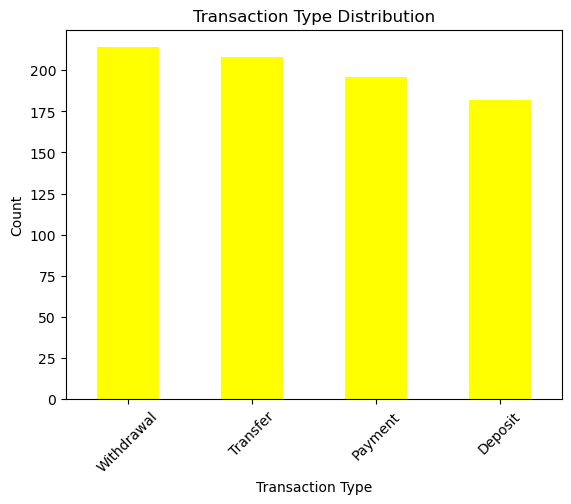

In [238]:
df['TransactionType'] = df['TransactionType'].astype(str).str.strip().str.title()

txn_counts = df['TransactionType'].value_counts()

plt.figure()
txn_counts.plot(kind='bar',color='yellow')
plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
df.reset_index(inplace=True)

#### Credits vs Debits Over Time
- This code converts the TransactionDate column into datetime format and sets it as the index for time-based analysis. It creates Credit and Debit columns by separating deposit amounts as credits and withdrawal, payment, or transfer amounts as debits. The data is then resampled monthly to calculate total credits and debits for each month. A line chart is plotted to compare monthly credits and debits over time. Finally, the DataFrame index is reset.


In [239]:
df.reset_index(inplace=True)

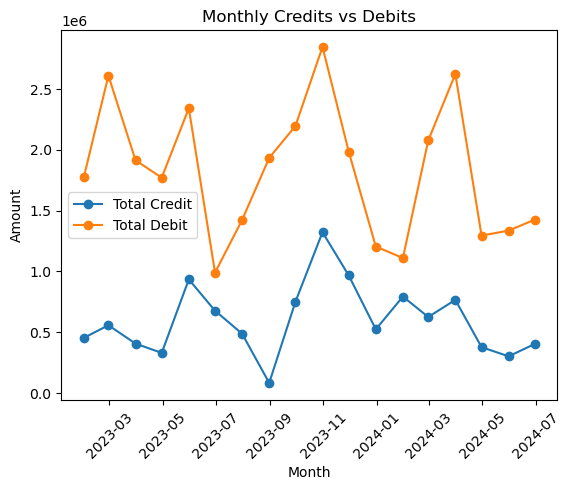

In [240]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True)

df.set_index('TransactionDate', inplace=True)

df['Credit'] = df['TransactionAmount'].where(df['TransactionType'] == 'Deposit', 0)
df['Debit'] = df['TransactionAmount'].where(df['TransactionType'].isin(["Withdrawal", "Payment",'Transfer']), 0)
monthly_summary = df.resample('ME')[['Credit', 'Debit']].sum()
plt.figure()
plt.plot(monthly_summary.index, monthly_summary['Credit'], marker='o', label='Total Credit')
plt.plot(monthly_summary.index, monthly_summary['Debit'], marker='o', label='Total Debit')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.title('Monthly Credits vs Debits')
plt.legend()
plt.xticks(rotation=45)
plt.show()
df.reset_index(inplace=True)

#### Account Balance Distribution
- This code creates a histogram of the AccountBalance column using 30 bins. It shows the distribution of account balances, where the x-axis represents balance amounts and the y-axis represents frequency. The chart helps visualize how account balances are spread across customers.


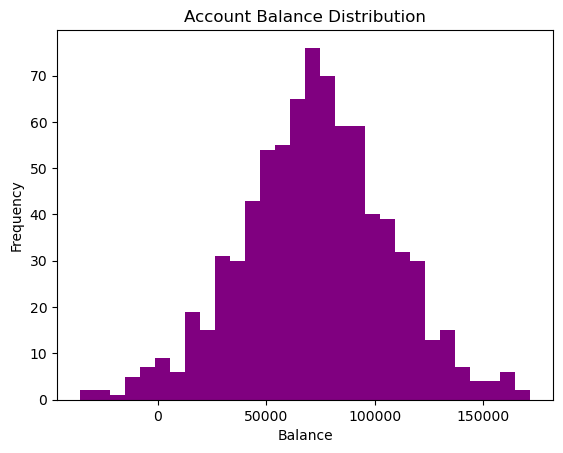

In [241]:
plt.figure()
plt.hist(df['AccountBalance'], bins=30,color='purple')
plt.title('Account Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()

#### Transaction Amount Distribution
- This code creates a box plot of the TransactionAmount column. It is used to visualize the spread of transaction amounts and detect outliers. The box shows the interquartile range, the center line represents the median, and points outside the whiskers indicate unusual transaction values.


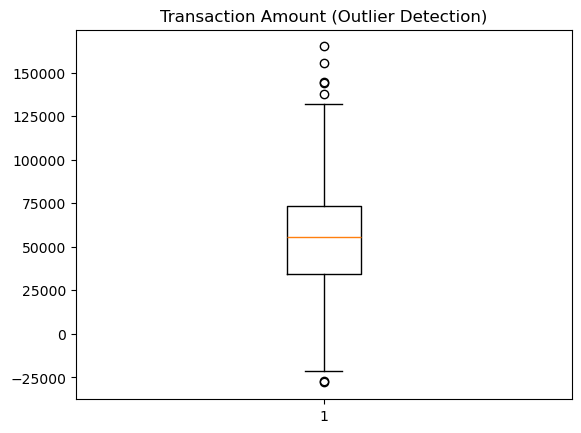

In [242]:
plt.figure()
plt.boxplot(df['TransactionAmount'])
plt.title('Transaction Amount (Outlier Detection)')
plt.show()

#### Activity Level Distribution¶
- This code groups the data by AccountID and counts the number of transactions for each account. It then plots a histogram to show the distribution of transaction frequency. The x-axis represents transactions per account, and the chart helps identify accounts with low or high activity levels.


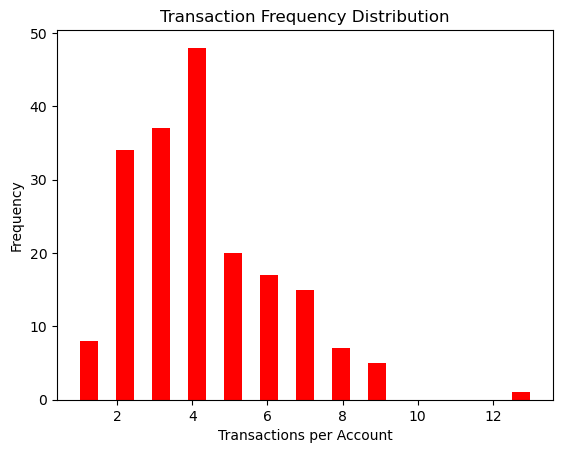

In [243]:
txn_count = df.groupby('AccountID').size()

plt.figure()
txn_count.plot(kind='hist', bins=25,color='red')
plt.title('Transaction Frequency Distribution')
plt.xlabel('Transactions per Account')
plt.show()

####  Top Accounts by Net flow¶
- This code calculates NetFlow by subtracting Debit from Credit for each transaction. It then groups the data by AccountID and sums the net flow for each account. The accounts are sorted in descending order, and the top 5 accounts with highest net flow are selected. Finally, a bar chart is plotted to display the top 5 accounts by net flow.


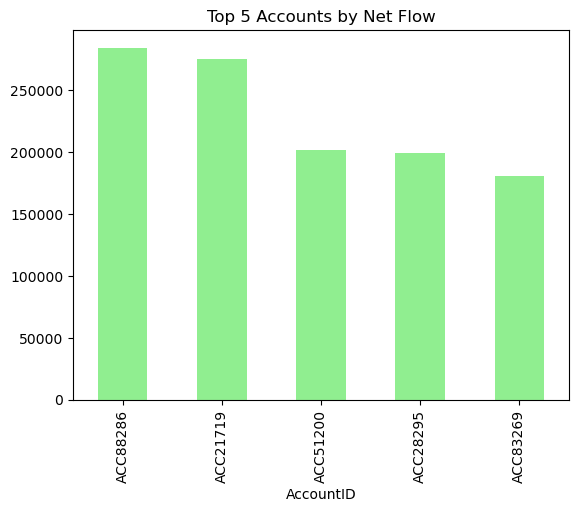

In [244]:
df['NetFlow'] = df['Credit'] - df['Debit']

account_flow = df.groupby('AccountID')['NetFlow'].sum().sort_values(ascending=False)

top5 = account_flow.head(5)

plt.figure()
top5.plot(kind='bar',color='lightgreen')
plt.title('Top 5 Accounts by Net Flow')
plt.show()

## 6. Hypothesis Testing
#### 6.1 Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.¶
- This code imports ttest_ind from scipy.stats to perform an independent t-test. It first calculates transaction count and average account balance for each AccountID, then merges both results into one summary table. Accounts are divided into high-volume and low-volume groups based on the median transaction count. A t-test is applied to compare the average balances of both groups. Finally, the t-statistic and p-value are printed, and a conclusion is made whether there is a significant difference in balances.


In [245]:
from scipy.stats import ttest_ind
# Step 1: Transaction count per account
txn_count = df.groupby('AccountID').size().reset_index(name='TxnCount')

# Step 2: Average balance per account
avg_balance = df.groupby('AccountID')['AccountBalance'].mean().reset_index()

# Merge both
summary = pd.merge(txn_count, avg_balance, on='AccountID')

# Step 3: Define threshold (median)
threshold = summary['TxnCount'].median()

# Split groups
high_volume = summary[summary['TxnCount'] >= threshold]['AccountBalance']
low_volume = summary[summary['TxnCount'] < threshold]['AccountBalance']

# Step 4: Perform t-test
t_stat, p_value = ttest_ind(high_volume, low_volume)

# Output
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

# Conclusion
if p_value < 0.05:
    print("Reject H0 → High-volume accounts have significantly higher balances")
else:
    print("Fail to reject H0 → No significant difference")

T-Statistic: -1.6362297951660512
P-Value: 0.10344688797510922
Fail to reject H0 → No significant difference


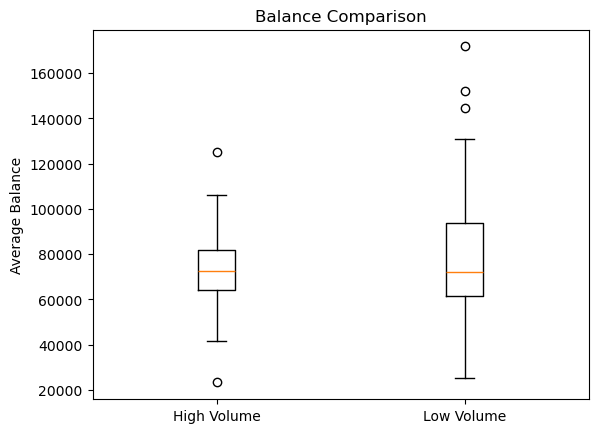

In [246]:
plt.boxplot([high_volume, low_volume], tick_labels=['High Volume', 'Low Volume'])
plt.title('Balance Comparison')
plt.ylabel('Average Balance')
plt.show()

#### 6.2 Conduct hypothesis testing based on segmentation.
- This code calculates transaction count and average account balance for each AccountID, then merges both results into one summary table. Accounts are segmented into High Activity and Low Activity groups based on the median transaction count. The account balances of both groups are separated, and Welch’s t-test is performed to compare their mean balances. Finally, the t-statistic and p-value are displayed, and a conclusion is given on whether there is a significant difference between the two segments.


In [247]:
# Step 1: Transaction count per account
txn_count = df.groupby('AccountID').size().reset_index(name='TxnCount')

# Step 2: Average balance per account
avg_balance = df.groupby('AccountID')['AccountBalance'].mean().reset_index()

# Merge
summary = pd.merge(txn_count, avg_balance, on='AccountID')

# Step 3: Segmentation (based on median)
threshold = summary['TxnCount'].median()

summary['Segment'] = summary['TxnCount'].apply(
    lambda x: 'High Activity' if x >= threshold else 'Low Activity'
)

# Step 4: Split groups
high_group = summary[summary['Segment'] == 'High Activity']['AccountBalance']
low_group = summary[summary['Segment'] == 'Low Activity']['AccountBalance']

# Step 5: Perform t-test (Welch's recommended)
t_stat, p_value = ttest_ind(high_group, low_group, equal_var=False)

# Output
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

# Conclusion
if p_value < 0.05:
    print("Reject H0 → Significant difference between segments")
else:
    print("Fail to reject H0 → No significant difference")

T-Statistic: -1.4829959732753735
P-Value: 0.14094274632649229
Fail to reject H0 → No significant difference


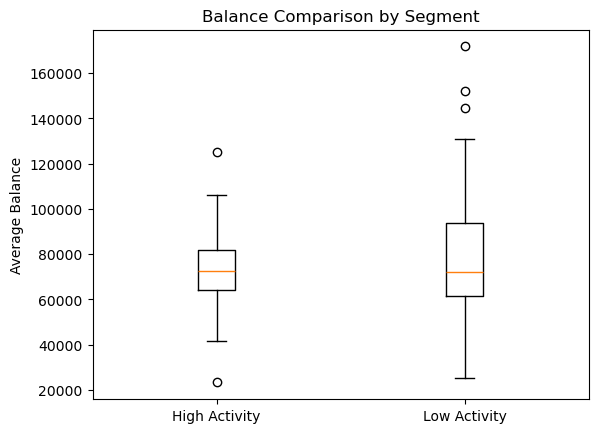

In [248]:
plt.boxplot([high_group, low_group], tick_labels=['High Activity', 'Low Activity'])
plt.title('Balance Comparison by Segment')
plt.ylabel('Average Balance')
plt.show()